In [1]:
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

ASCAD_PATH = "/kaggle/input/datasets/govindgopa/ascad-data/ASCAD_data/ASCAD_databases/ASCAD.h5"

np.random.seed(42)
tf.random.set_seed(42)

2026-06-18 07:50:17.891360: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781769018.045457      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781769018.092077      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781769018.465428      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781769018.465467      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781769018.465469      58 computation_placer.cc:177] computation placer alr

In [2]:
with h5py.File(ASCAD_PATH, "r") as f:
    X_prof_raw = f["Profiling_traces"]["traces"][:].astype("float32")
    y_prof = f["Profiling_traces"]["labels"][:].astype("int64")

    X_attack_raw = f["Attack_traces"]["traces"][:].astype("float32")
    y_attack = f["Attack_traces"]["labels"][:].astype("int64")

    prof_metadata = f["Profiling_traces"]["metadata"]
    attack_metadata = f["Attack_traces"]["metadata"]

    masks_prof = np.stack([
        prof_metadata[i]["masks"] for i in range(len(prof_metadata))
    ])

    plaintexts_attack = np.array([
        attack_metadata[i]["plaintext"][2] for i in range(len(attack_metadata))
    ])

    keys_attack = np.array([
        attack_metadata[i]["key"][2] for i in range(len(attack_metadata))
    ])

print("Profiling traces:", X_prof_raw.shape)
print("Attack traces:", X_attack_raw.shape)
print("Profiling labels:", y_prof.shape)
print("Attack labels:", y_attack.shape)
print("Masks:", masks_prof.shape)

Profiling traces: (50000, 700)
Attack traces: (10000, 700)
Profiling labels: (50000,)
Attack labels: (10000,)
Masks: (50000, 16)


In [3]:
sbox = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
], dtype=np.uint8)

In [4]:
def softmax_np(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)


def compute_key_rank(logits, plaintexts, keys, seed=None):
    rng = np.random.default_rng(seed)

    n_traces = logits.shape[0]
    order = rng.permutation(n_traces)

    logits = logits[order]
    plaintexts = plaintexts[order]
    keys = keys[order]

    probs = softmax_np(logits)
    log_probs = np.log(probs + 1e-40)

    key_scores = np.zeros(256, dtype=np.float64)
    ranks = np.zeros(n_traces, dtype=np.int64)

    key_guesses = np.arange(256, dtype=np.uint8)

    for i in range(n_traces):
        pt = np.uint8(plaintexts[i])
        true_key = int(keys[i])

        sbox_values = sbox[np.bitwise_xor(pt, key_guesses)]

        key_scores += log_probs[i, sbox_values]

        sorted_keys = np.argsort(-key_scores)
        ranks[i] = np.where(sorted_keys == true_key)[0][0]

    return ranks


def compute_mean_key_rank(logits, plaintexts, keys, n_runs=100, name="model"):
    all_ranks = []

    for run in range(n_runs):
        ranks = compute_key_rank(
            logits,
            plaintexts,
            keys,
            seed=run
        )
        all_ranks.append(ranks)

    all_ranks = np.stack(all_ranks, axis=0)
    mean_rank = all_ranks.mean(axis=0)

    print(f"\n{name}")
    print("Mean key rank after 1 trace:", mean_rank[0])
    print("Mean key rank after 10 traces:", mean_rank[9])
    print("Mean key rank after 50 traces:", mean_rank[49])
    print("Mean key rank after 100 traces:", mean_rank[99])
    print("Mean key rank after 500 traces:", mean_rank[499])
    print("Mean key rank after 1000 traces:", mean_rank[999])
    print("Mean key rank after 5000 traces:", mean_rank[4999])
    print("Final mean key rank:", mean_rank[-1])

    return mean_rank, all_ranks

In [6]:
trace_mean = X_prof_raw.mean(axis=0)

X_prof_c = X_prof_raw - trace_mean
X_attack_c = X_attack_raw - trace_mean

print("Centered profiling mean:", X_prof_c.mean())
print("Centered profiling std:", X_prof_c.std())

Centered profiling mean: 4.2857142e-08
Centered profiling std: 2.5110068


In [7]:
def compute_snr(X, labels, n_classes=256):
    X = X.astype("float32")
    labels = labels.astype("int64")

    class_means = []
    class_vars = []

    for c in range(n_classes):
        idx = np.where(labels == c)[0]

        if len(idx) < 2:
            continue

        Xc = X[idx]
        class_means.append(Xc.mean(axis=0))
        class_vars.append(Xc.var(axis=0))

    class_means = np.stack(class_means, axis=0)
    class_vars = np.stack(class_vars, axis=0)

    signal = class_means.var(axis=0)
    noise = class_vars.mean(axis=0) + 1e-12

    return signal / noise

In [10]:
trace_mean = X_prof_raw.mean(axis=0)

X_prof_c = X_prof_raw - trace_mean
X_attack_c = X_attack_raw - trace_mean

print(X_prof_c.shape)
print(X_attack_c.shape)

(50000, 700)
(10000, 700)


Mask POIs: [ 35  99 129 133 135 197 214 215 223 224 225 226 227 237 239 240 242 244
 269 270 298 310 311 352 368 432 455 456 457 462 463 470 471 472 473 474
 475 480 481 487 489 505 506 526 528 529 535 536 551 554 555 556 560 585
 597 609 610 611 628 642 652 654 660 674]
Masked-value POIs: [ 91 115 128 323 351 357 358 359 360 361 375 376 388 389 390 391 392 409
 410 411 412 413 414 415 416 417 418 427 440 441 442 443 444 455 507 514
 548 565 566 567 568 569 573 596 597 598 599 600 618 619 620 621 624 625
 626 627 636 650 651 652 653 670 687 688]


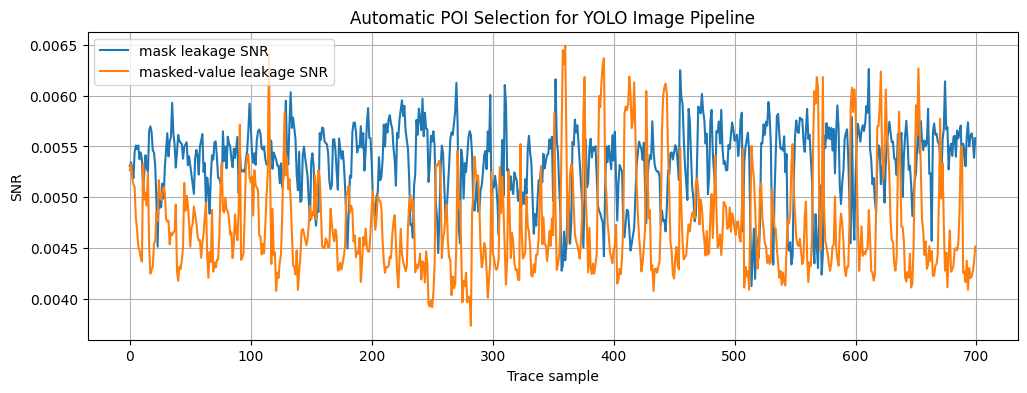

In [11]:
top_k = 64
mask_idx = 2

mask_label = masks_prof[:, mask_idx].astype("int64")
masked_value_label = np.bitwise_xor(y_prof, mask_label).astype("int64")

snr_mask = compute_snr(X_prof_c, mask_label)
snr_masked_value = compute_snr(X_prof_c, masked_value_label)

poi_mask = np.sort(np.argsort(snr_mask)[-top_k:])
poi_masked_value = np.sort(np.argsort(snr_masked_value)[-top_k:])

print("Mask POIs:", poi_mask)
print("Masked-value POIs:", poi_masked_value)

plt.figure(figsize=(12, 4))
plt.plot(snr_mask, label="mask leakage SNR")
plt.plot(snr_masked_value, label="masked-value leakage SNR")
plt.xlabel("Trace sample")
plt.ylabel("SNR")
plt.title("Automatic POI Selection for YOLO Image Pipeline")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
print("X_prof_raw exists:", "X_prof_raw" in globals())
print("X_prof_c exists:", "X_prof_c" in globals())
print("compute_snr exists:", "compute_snr" in globals())

X_prof_raw exists: True
X_prof_c exists: False
compute_snr exists: True


In [12]:
A_prof = X_prof_c[:, poi_mask]
B_prof = X_prof_c[:, poi_masked_value]

A_attack = X_attack_c[:, poi_mask]
B_attack = X_attack_c[:, poi_masked_value]

A_mean = A_prof.mean(axis=0)
A_std = A_prof.std(axis=0) + 1e-8

B_mean = B_prof.mean(axis=0)
B_std = B_prof.std(axis=0) + 1e-8

A_prof = (A_prof - A_mean) / A_std
B_prof = (B_prof - B_mean) / B_std

A_attack = (A_attack - A_mean) / A_std
B_attack = (B_attack - B_mean) / B_std

print(A_prof.shape, B_prof.shape)
print(A_attack.shape, B_attack.shape)

(50000, 64) (50000, 64)
(10000, 64) (10000, 64)


In [13]:
def compute_product_stats(A, B, batch_size=2048):
    k = A.shape[1]

    p_sum = np.zeros((k, k), dtype=np.float64)
    p_sq_sum = np.zeros((k, k), dtype=np.float64)
    n = 0

    for start in range(0, len(A), batch_size):
        end = start + batch_size

        Ab = A[start:end]
        Bb = B[start:end]

        P = Ab[:, :, None] * Bb[:, None, :]

        p_sum += P.sum(axis=0)
        p_sq_sum += (P ** 2).sum(axis=0)
        n += P.shape[0]

    p_mean = p_sum / n
    p_var = (p_sq_sum / n) - (p_mean ** 2)
    p_std = np.sqrt(np.maximum(p_var, 1e-8))

    return p_mean.astype("float32"), p_std.astype("float32")

In [14]:
P_mean, P_std = compute_product_stats(A_prof, B_prof)

print(P_mean.shape, P_std.shape)
print(P_mean.mean(), P_std.mean())

(64, 64) (64, 64)
0.07321168 1.0160825


In [15]:
A_val = A_prof[-5000:]
B_val = B_prof[-5000:]
y_val = y_prof[-5000:]

A_train = A_prof[:-5000]
B_train = B_prof[:-5000]
y_train = y_prof[:-5000]

print("Train:", A_train.shape, B_train.shape, y_train.shape)
print("Val:", A_val.shape, B_val.shape, y_val.shape)
print("Attack:", A_attack.shape, B_attack.shape, y_attack.shape)

Train: (45000, 64) (45000, 64) (45000,)
Val: (5000, 64) (5000, 64) (5000,)
Attack: (10000, 64) (10000, 64) (10000,)


In [16]:
P_mean_tf = tf.constant(P_mean, dtype=tf.float32)
P_std_tf = tf.constant(P_std, dtype=tf.float32)

def make_yolo_image(A, B, y):
    A = tf.cast(A, tf.float32)
    B = tf.cast(B, tf.float32)

    P = A[:, None] * B[None, :]
    P = (P - P_mean_tf) / P_std_tf

    A_img = tf.tile(A[:, None], [1, top_k])
    B_img = tf.tile(B[None, :], [top_k, 1])

    img = tf.stack([P, A_img, B_img], axis=-1)

    return img, y

I0000 00:00:1781769404.706068      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781769404.712010      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [17]:
batch_size = 256
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices(
    (A_train.astype("float32"), B_train.astype("float32"), y_train.astype("int64"))
)

train_ds = (
    train_ds
    .shuffle(20000, seed=42, reshuffle_each_iteration=True)
    .map(make_yolo_image, num_parallel_calls=AUTOTUNE)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (A_val.astype("float32"), B_val.astype("float32"), y_val.astype("int64"))
)

val_ds = (
    val_ds
    .map(make_yolo_image, num_parallel_calls=AUTOTUNE)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

attack_ds = tf.data.Dataset.from_tensor_slices(
    (A_attack.astype("float32"), B_attack.astype("float32"), y_attack.astype("int64"))
)

attack_ds = (
    attack_ds
    .map(make_yolo_image, num_parallel_calls=AUTOTUNE)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

In [18]:
def conv_bn_silu(x, filters, kernel_size=3, strides=1, name=None):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=None if name is None else name + "_conv"
    )(x)

    x = layers.BatchNormalization(
        name=None if name is None else name + "_bn"
    )(x)

    x = layers.Activation(
        "swish",
        name=None if name is None else name + "_silu"
    )(x)

    return x

In [19]:
def bottleneck(x, filters, shortcut=True, name=None):
    hidden = max(filters // 2, 16)

    y = conv_bn_silu(
        x,
        hidden,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_cv1"
    )

    y = conv_bn_silu(
        y,
        filters,
        kernel_size=3,
        strides=1,
        name=None if name is None else name + "_cv2"
    )

    if shortcut and x.shape[-1] == filters:
        y = layers.Add(name=None if name is None else name + "_add")([x, y])

    return y

In [27]:
def c2f_block(x, filters, n=2, name=None):
    y = conv_bn_silu(
        x,
        filters,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_cv1"
    )

    half = filters // 2

    # Keras-safe split instead of tf.split()
    y1 = layers.Lambda(
        lambda t: t[..., :half],
        name=None if name is None else name + "_split_1"
    )(y)

    y2 = layers.Lambda(
        lambda t: t[..., half:],
        name=None if name is None else name + "_split_2"
    )(y)

    outputs = [y1, y2]
    current = y2

    for i in range(n):
        current = bottleneck(
            current,
            half,
            shortcut=True,
            name=None if name is None else name + f"_bottleneck_{i}"
        )

        outputs.append(current)

    y = layers.Concatenate(
        axis=-1,
        name=None if name is None else name + "_concat"
    )(outputs)

    y = conv_bn_silu(
        y,
        filters,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_cv2"
    )

    return y

In [21]:
def sppf_block(x, filters, name=None):
    x = conv_bn_silu(
        x,
        filters // 2,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_cv1"
    )

    y1 = layers.MaxPooling2D(pool_size=5, strides=1, padding="same")(x)
    y2 = layers.MaxPooling2D(pool_size=5, strides=1, padding="same")(y1)
    y3 = layers.MaxPooling2D(pool_size=5, strides=1, padding="same")(y2)

    y = layers.Concatenate(axis=-1)([x, y1, y2, y3])

    y = conv_bn_silu(
        y,
        filters,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_cv2"
    )

    return y

In [22]:
def build_yolov8_sca_classifier(
    input_shape=(64, 64, 3),
    num_classes=256,
    width=1.0
):
    inputs = layers.Input(shape=input_shape)

    f1 = int(32 * width)
    f2 = int(64 * width)
    f3 = int(128 * width)
    f4 = int(256 * width)

    x = conv_bn_silu(inputs, f1, 3, 2, name="stem")

    x = conv_bn_silu(x, f2, 3, 2, name="stage1_down")
    x = c2f_block(x, f2, n=2, name="stage1_c2f")

    x = conv_bn_silu(x, f3, 3, 2, name="stage2_down")
    x = c2f_block(x, f3, n=3, name="stage2_c2f")

    x = conv_bn_silu(x, f4, 3, 2, name="stage3_down")
    x = c2f_block(x, f4, n=3, name="stage3_c2f")

    x = sppf_block(x, f4, name="sppf")

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(256, activation="swish")(x)
    x = layers.Dropout(0.15)(x)

    outputs = layers.Dense(num_classes)(x)

    model = tf.keras.Model(inputs, outputs, name="YOLOv8_SCA_Classifier")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    return model

In [23]:
def c3k2_block(x, filters, n=2, name=None):
    y = conv_bn_silu(
        x,
        filters,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_cv1"
    )

    shortcut = y

    for i in range(n):
        y = conv_bn_silu(
            y,
            filters,
            kernel_size=3,
            strides=1,
            name=None if name is None else name + f"_k3a_{i}"
        )

        y = conv_bn_silu(
            y,
            filters,
            kernel_size=3,
            strides=1,
            name=None if name is None else name + f"_k3b_{i}"
        )

    if shortcut.shape[-1] == y.shape[-1]:
        y = layers.Add(name=None if name is None else name + "_add")([shortcut, y])

    return y

In [24]:
def psa_block(x, filters, name=None):
    # Lightweight spatial/channel attention inspired by YOLO11-style PSA idea.
    shortcut = x

    x = conv_bn_silu(
        x,
        filters,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_proj"
    )

    # Channel attention
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Dense(max(filters // 4, 16), activation="swish")(gap)
    gap = layers.Dense(filters, activation="sigmoid")(gap)
    gap = layers.Reshape((1, 1, filters))(gap)

    x = layers.Multiply()([x, gap])

    # Spatial attention
    spatial = layers.Conv2D(
        1,
        kernel_size=7,
        padding="same",
        activation="sigmoid",
        name=None if name is None else name + "_spatial"
    )(x)

    x = layers.Multiply()([x, spatial])

    if shortcut.shape[-1] == x.shape[-1]:
        x = layers.Add()([shortcut, x])

    return x

In [25]:
def build_yolo11_sca_classifier(
    input_shape=(64, 64, 3),
    num_classes=256,
    width=1.0
):
    inputs = layers.Input(shape=input_shape)

    f1 = int(32 * width)
    f2 = int(64 * width)
    f3 = int(128 * width)
    f4 = int(256 * width)

    x = conv_bn_silu(inputs, f1, 3, 2, name="stem")

    x = conv_bn_silu(x, f2, 3, 2, name="stage1_down")
    x = c3k2_block(x, f2, n=1, name="stage1_c3k2")

    x = conv_bn_silu(x, f3, 3, 2, name="stage2_down")
    x = c3k2_block(x, f3, n=2, name="stage2_c3k2")
    x = psa_block(x, f3, name="stage2_psa")

    x = conv_bn_silu(x, f4, 3, 2, name="stage3_down")
    x = c3k2_block(x, f4, n=2, name="stage3_c3k2")
    x = psa_block(x, f4, name="stage3_psa")

    x = sppf_block(x, f4, name="sppf")

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(256, activation="swish")(x)
    x = layers.Dropout(0.15)(x)

    outputs = layers.Dense(num_classes)(x)

    model = tf.keras.Model(inputs, outputs, name="YOLO11_SCA_Classifier")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    return model

In [28]:
tf.keras.backend.clear_session()

yolov8_sca = build_yolov8_sca_classifier(
    input_shape=(64, 64, 3),
    num_classes=256,
    width=1.0
)

yolov8_sca.summary()

Model: "YOLOv8_SCA_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_silu           │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_down_conv    │ (None, 16, 16,    │     18,432 │ stem_silu[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_down_bn      │ (None, 16, 16,    │        256 │ stage1_down_conv… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_down_silu    │ (None, 16, 16,    │          0 │ stage1_down_bn[0… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c2f_cv1_conv │ (None, 16, 16,    │      4,096 │ stage1_down_silu… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c2f_cv1_bn   │ (None, 16, 16,    │        256 │ stage1_c2f_cv1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c2f_cv1_silu │ (None, 16, 16,    │          0 │ stage1_c2f_cv1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c2f_split_2  │ (None, 16, 16,    │          0 │ stage1_c2f_cv1_s… │
│ (Lambda)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c2f_bottlen… │ (None, 16, 16,    │        512 │ stage1_c2f_split… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c2f_bottlen… │ (None, 16, 16,    │         64 │ stage1_c2f_bottl… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c2f_bottlen… │ (None, 16, 16,    │          0 │ stage1_c2f_bottl… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c2f_bottlen… │ (None, 16, 16,    │      4,608 │ stage1_c2f_bottl… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c2f_bottlen… │ (None, 16, 16,    │        128 │ stage1_c2f_bottl… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c2f_bottlen… │ (None, 16, 16,    │          0 │ stage1_c2f_bottl

 Total params: 1,310,688 (5.00 MB)

 Trainable params: 1,305,248 (4.98 MB)

 Non-trainable params: 5,440 (21.25 KB)

In [29]:
callbacks_v8 = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_yolov8_sca_top64.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

history_v8 = yolov8_sca.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=callbacks_v8,
    verbose=1
)

Epoch 1/150


I0000 00:00:1781769730.135825     145 service.cc:152] XLA service 0x789004002cc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781769730.135867     145 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781769730.135873     145 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781769732.585450     145 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/176 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.0043 - loss: 5.6878 

I0000 00:00:1781769746.015413     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 151ms/step - accuracy: 0.0033 - loss: 5.5654 - val_accuracy: 0.0022 - val_loss: 5.5495 - learning_rate: 5.0000e-04
Epoch 2/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.0040 - loss: 5.5480 - val_accuracy: 0.0032 - val_loss: 5.5495 - learning_rate: 5.0000e-04
Epoch 3/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.0047 - loss: 5.5456 - val_accuracy: 0.0030 - val_loss: 5.5490 - learning_rate: 5.0000e-04
Epoch 4/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.0041 - loss: 5.5442 - val_accuracy: 0.0026 - val_loss: 5.5483 - learning_rate: 5.0000e-04
Epoch 5/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0050 - loss: 5.5420 - val_accuracy: 0.0026 - val_loss: 5.5497 - learning_rate: 5.0000e-04
Epoch 6/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0057 - loss: 5.5403 - val_accuracy: 0.0024 - val_loss: 5.5513 - learning_rate: 5.0000e-04
Epoch 7/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accura

In [30]:
attack_loss_v8, attack_acc_v8 = yolov8_sca.evaluate(
    attack_ds,
    verbose=1
)

print("YOLOv8-SCA attack loss:", attack_loss_v8)
print("YOLOv8-SCA attack accuracy:", attack_acc_v8)

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.0029 - loss: 5.5512
YOLOv8-SCA attack loss: 5.551150321960449
YOLOv8-SCA attack accuracy: 0.002899999963119626


In [31]:
test_scores_v8 = yolov8_sca.predict(
    attack_ds,
    verbose=1
)

print("YOLOv8 scores:", test_scores_v8.shape)

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step
YOLOv8 scores: (10000, 256)


In [32]:
mean_key_rank_v8, key_rank_runs_v8 = compute_mean_key_rank(
    test_scores_v8,
    plaintexts_attack,
    keys_attack,
    n_runs=100,
    name="YOLOv8-SCA top64"
)


YOLOv8-SCA top64
Mean key rank after 1 trace: 134.36
Mean key rank after 10 traces: 132.9
Mean key rank after 50 traces: 135.25
Mean key rank after 100 traces: 136.06
Mean key rank after 500 traces: 150.64
Mean key rank after 1000 traces: 158.68
Mean key rank after 5000 traces: 205.96
Final mean key rank: 236.0


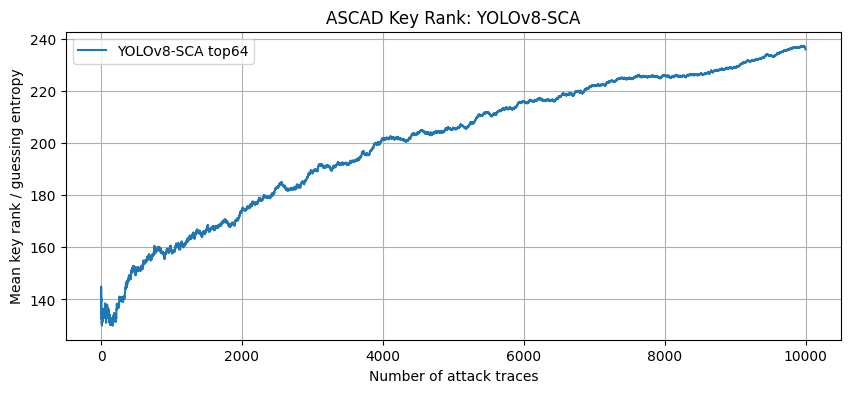

In [33]:
plt.figure(figsize=(10, 4))
plt.plot(mean_key_rank_v8, label="YOLOv8-SCA top64")

try:
    plt.plot(mean_key_rank_ensemble_64_96, label="Second-order MLP ensemble")
except NameError:
    pass

plt.xlabel("Number of attack traces")
plt.ylabel("Mean key rank / guessing entropy")
plt.title("ASCAD Key Rank: YOLOv8-SCA")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
tf.keras.backend.clear_session()

yolo11_sca = build_yolo11_sca_classifier(
    input_shape=(64, 64, 3),
    num_classes=256,
    width=1.0
)

yolo11_sca.summary()

Model: "YOLO11_SCA_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_silu           │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_down_conv    │ (None, 16, 16,    │     18,432 │ stem_silu[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_down_bn      │ (None, 16, 16,    │        256 │ stage1_down_conv… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_down_silu    │ (None, 16, 16,    │          0 │ stage1_down_bn[0… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c3k2_cv1_co… │ (None, 16, 16,    │      4,096 │ stage1_down_silu… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c3k2_cv1_bn  │ (None, 16, 16,    │        256 │ stage1_c3k2_cv1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c3k2_cv1_si… │ (None, 16, 16,    │          0 │ stage1_c3k2_cv1_… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c3k2_k3a_0_… │ (None, 16, 16,    │     36,864 │ stage1_c3k2_cv1_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c3k2_k3a_0_… │ (None, 16, 16,    │        256 │ stage1_c3k2_k3a_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c3k2_k3a_0_… │ (None, 16, 16,    │          0 │ stage1_c3k2_k3a_… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c3k2_k3b_0_… │ (None, 16, 16,    │     36,864 │ stage1_c3k2_k3a_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c3k2_k3b_0_… │ (None, 16, 16,    │        256 │ stage1_c3k2_k3b_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c3k2_k3b_0_… │ (None, 16, 16,    │          0 │ stage1_c3k2_k3b_… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_c3k2_add     │ (None, 16, 16,    │          0 │ stage1_c3k2_cv1_

 Total params: 3,947,842 (15.06 MB)

 Trainable params: 3,941,122 (15.03 MB)

 Non-trainable params: 6,720 (26.25 KB)

In [35]:
callbacks_11 = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_yolo11_sca_top64.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

history_11 = yolo11_sca.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=callbacks_11,
    verbose=1
)

Epoch 1/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 51s 155ms/step - accuracy: 0.0037 - loss: 5.5672 - val_accuracy: 0.0040 - val_loss: 5.5479 - learning_rate: 5.0000e-04
Epoch 2/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.0044 - loss: 5.5465 - val_accuracy: 0.0036 - val_loss: 5.5484 - learning_rate: 5.0000e-04
Epoch 3/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.0055 - loss: 5.5436 - val_accuracy: 0.0032 - val_loss: 5.5493 - learning_rate: 5.0000e-04
Epoch 4/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.0054 - loss: 5.5403 - val_accuracy: 0.0034 - val_loss: 5.5481 - learning_rate: 5.0000e-04
Epoch 5/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.0054 - loss: 5.5351 - val_accuracy: 0.0046 - val_loss: 5.5513 - learning_rate: 5.0000e-04
Epoch 6/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.0067 - loss: 5.5260 - val_accuracy: 0.0040 - val_loss: 5.5549 - learning_rate: 5.0000e-04
Epoch 7/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 6

In [36]:
attack_loss_11, attack_acc_11 = yolo11_sca.evaluate(
    attack_ds,
    verbose=1
)

print("YOLO11-SCA attack loss:", attack_loss_11)
print("YOLO11-SCA attack accuracy:", attack_acc_11)

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.0040 - loss: 5.5502
YOLO11-SCA attack loss: 5.5502142906188965
YOLO11-SCA attack accuracy: 0.004000000189989805


In [37]:
test_scores_11 = yolo11_sca.predict(
    attack_ds,
    verbose=1
)

print("YOLO11 scores:", test_scores_11.shape)

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step
YOLO11 scores: (10000, 256)


In [38]:
mean_key_rank_11, key_rank_runs_11 = compute_mean_key_rank(
    test_scores_11,
    plaintexts_attack,
    keys_attack,
    n_runs=100,
    name="YOLO11-SCA top64"
)


YOLO11-SCA top64
Mean key rank after 1 trace: 133.48
Mean key rank after 10 traces: 132.18
Mean key rank after 50 traces: 119.56
Mean key rank after 100 traces: 128.24
Mean key rank after 500 traces: 136.17
Mean key rank after 1000 traces: 149.8
Mean key rank after 5000 traces: 179.86
Final mean key rank: 210.0


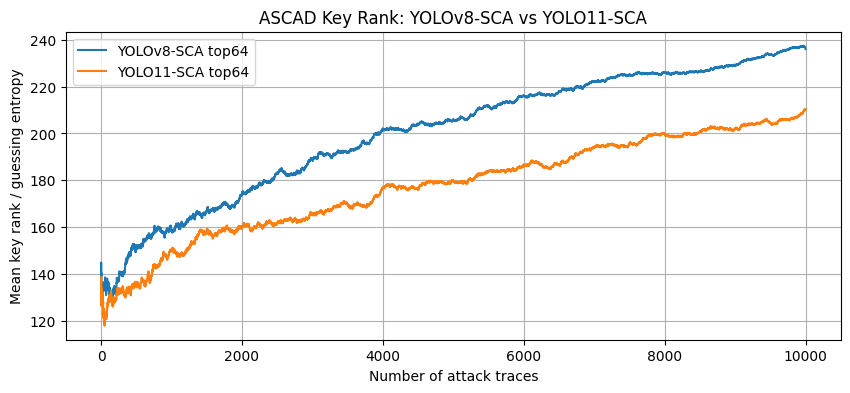

In [39]:
plt.figure(figsize=(10, 4))
plt.plot(mean_key_rank_v8, label="YOLOv8-SCA top64")
plt.plot(mean_key_rank_11, label="YOLO11-SCA top64")

try:
    plt.plot(mean_key_rank_ensemble_64_96, label="Second-order MLP ensemble")
except NameError:
    pass

plt.xlabel("Number of attack traces")
plt.ylabel("Mean key rank / guessing entropy")
plt.title("ASCAD Key Rank: YOLOv8-SCA vs YOLO11-SCA")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
np.savetxt(
    "/kaggle/working/yolov8_sca_top64_mean_key_rank.txt",
    mean_key_rank_v8
)

np.savetxt(
    "/kaggle/working/yolo11_sca_top64_mean_key_rank.txt",
    mean_key_rank_11
)

np.savez(
    "/kaggle/working/yolo_sca_top64_results.npz",
    mean_key_rank_v8=mean_key_rank_v8,
    mean_key_rank_11=mean_key_rank_11,
    key_rank_runs_v8=key_rank_runs_v8,
    key_rank_runs_11=key_rank_runs_11,
    poi_mask=poi_mask,
    poi_masked_value=poi_masked_value,
    A_mean=A_mean,
    A_std=A_std,
    B_mean=B_mean,
    B_std=B_std,
    P_mean=P_mean,
    P_std=P_std,
    trace_mean=trace_mean
)

yolov8_sca.save("/kaggle/working/final_yolov8_sca_top64.keras")
yolo11_sca.save("/kaggle/working/final_yolo11_sca_top64.keras")

print("Saved YOLOv8-SCA and YOLO11-SCA results.")

Saved YOLOv8-SCA and YOLO11-SCA results.


In [41]:
mean_key_rank_v8_neg, _ = compute_mean_key_rank(
    -test_scores_v8,
    plaintexts_attack,
    keys_attack,
    n_runs=100,
    name="YOLOv8-SCA negative logits"
)

mean_key_rank_11_neg, _ = compute_mean_key_rank(
    -test_scores_11,
    plaintexts_attack,
    keys_attack,
    n_runs=100,
    name="YOLO11-SCA negative logits"
)


YOLOv8-SCA negative logits
Mean key rank after 1 trace: 120.64
Mean key rank after 10 traces: 122.1
Mean key rank after 50 traces: 119.75
Mean key rank after 100 traces: 118.94
Mean key rank after 500 traces: 104.36
Mean key rank after 1000 traces: 96.32
Mean key rank after 5000 traces: 49.04
Final mean key rank: 19.0

YOLO11-SCA negative logits
Mean key rank after 1 trace: 121.52
Mean key rank after 10 traces: 122.82
Mean key rank after 50 traces: 135.44
Mean key rank after 100 traces: 126.76
Mean key rank after 500 traces: 118.83
Mean key rank after 1000 traces: 105.2
Mean key rank after 5000 traces: 75.14
Final mean key rank: 45.0


##### YOLO v2 begins below

In [42]:
required_vars = [
    "A_train", "B_train", "y_train",
    "A_val", "B_val", "y_val",
    "A_attack", "B_attack", "y_attack",
    "P_mean", "P_std",
    "top_k",
    "plaintexts_attack", "keys_attack",
    "compute_mean_key_rank"
]

for v in required_vars:
    print(v, v in globals())

A_train True
B_train True
y_train True
A_val True
B_val True
y_val True
A_attack True
B_attack True
y_attack True
P_mean True
P_std True
top_k True
plaintexts_attack True
keys_attack True
compute_mean_key_rank True


In [43]:
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

with h5py.File(ASCAD_PATH, "r") as f:
    prof_metadata = f["Profiling_traces"]["metadata"]

    plaintexts_prof = np.array([
        prof_metadata[i]["plaintext"][2] for i in range(len(prof_metadata))
    ])

    keys_prof = np.array([
        prof_metadata[i]["key"][2] for i in range(len(prof_metadata))
    ])

plaintexts_val = plaintexts_prof[-5000:]
keys_val = keys_prof[-5000:]

print(plaintexts_val.shape, keys_val.shape)

(5000,) (5000,)


In [44]:
P_mean_tf = tf.constant(P_mean, dtype=tf.float32)
P_std_tf = tf.constant(P_std, dtype=tf.float32)

coord = np.linspace(-1.0, 1.0, top_k).astype("float32")

row_coord_np = np.tile(coord[:, None], (1, top_k))
col_coord_np = np.tile(coord[None, :], (top_k, 1))

ROW_COORD = tf.constant(row_coord_np, dtype=tf.float32)
COL_COORD = tf.constant(col_coord_np, dtype=tf.float32)

def make_yolo_image_v2(A, B, y):
    A = tf.cast(A, tf.float32)
    B = tf.cast(B, tf.float32)

    P = A[:, None] * B[None, :]
    P = (P - P_mean_tf) / P_std_tf

    A_img = tf.tile(A[:, None], [1, top_k])
    B_img = tf.tile(B[None, :], [top_k, 1])

    img = tf.stack(
        [P, A_img, B_img, ROW_COORD, COL_COORD],
        axis=-1
    )

    img.set_shape((top_k, top_k, 5))

    return img, y

In [45]:
batch_size_v2 = 128
AUTOTUNE = tf.data.AUTOTUNE

train_ds_v2 = tf.data.Dataset.from_tensor_slices(
    (A_train.astype("float32"), B_train.astype("float32"), y_train.astype("int64"))
)

train_ds_v2 = (
    train_ds_v2
    .shuffle(20000, seed=42, reshuffle_each_iteration=True)
    .map(make_yolo_image_v2, num_parallel_calls=AUTOTUNE)
    .batch(batch_size_v2)
    .prefetch(AUTOTUNE)
)

val_ds_v2 = tf.data.Dataset.from_tensor_slices(
    (A_val.astype("float32"), B_val.astype("float32"), y_val.astype("int64"))
)

val_ds_v2 = (
    val_ds_v2
    .map(make_yolo_image_v2, num_parallel_calls=AUTOTUNE)
    .batch(batch_size_v2)
    .prefetch(AUTOTUNE)
)

attack_ds_v2 = tf.data.Dataset.from_tensor_slices(
    (A_attack.astype("float32"), B_attack.astype("float32"), y_attack.astype("int64"))
)

attack_ds_v2 = (
    attack_ds_v2
    .map(make_yolo_image_v2, num_parallel_calls=AUTOTUNE)
    .batch(batch_size_v2)
    .prefetch(AUTOTUNE)
)

In [46]:
def conv_bn_silu_v2(x, filters, kernel_size=3, strides=1, name=None):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=None if name is None else name + "_conv"
    )(x)

    x = layers.BatchNormalization(
        name=None if name is None else name + "_bn"
    )(x)

    x = layers.Activation(
        "swish",
        name=None if name is None else name + "_silu"
    )(x)

    return x


def bottleneck_v2(x, filters, shortcut=True, name=None):
    hidden = max(filters // 2, 16)

    y = conv_bn_silu_v2(
        x,
        hidden,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_cv1"
    )

    y = conv_bn_silu_v2(
        y,
        filters,
        kernel_size=3,
        strides=1,
        name=None if name is None else name + "_cv2"
    )

    if shortcut and x.shape[-1] == filters:
        y = layers.Add(name=None if name is None else name + "_add")([x, y])

    return y

In [47]:
def c2f_block_v2(x, filters, n=2, name=None):
    y = conv_bn_silu_v2(
        x,
        filters,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_cv1"
    )

    half = filters // 2

    y1 = layers.Lambda(
        lambda t: t[..., :half],
        name=None if name is None else name + "_split_1"
    )(y)

    y2 = layers.Lambda(
        lambda t: t[..., half:],
        name=None if name is None else name + "_split_2"
    )(y)

    outputs = [y1, y2]
    current = y2

    for i in range(n):
        current = bottleneck_v2(
            current,
            half,
            shortcut=True,
            name=None if name is None else name + f"_bottleneck_{i}"
        )

        outputs.append(current)

    y = layers.Concatenate(
        axis=-1,
        name=None if name is None else name + "_concat"
    )(outputs)

    y = conv_bn_silu_v2(
        y,
        filters,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_cv2"
    )

    return y

In [48]:
def c3k2_block_v2(x, filters, n=2, name=None):
    y = conv_bn_silu_v2(
        x,
        filters,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_cv1"
    )

    shortcut = y

    for i in range(n):
        y = conv_bn_silu_v2(
            y,
            filters,
            kernel_size=3,
            strides=1,
            name=None if name is None else name + f"_k3a_{i}"
        )

        y = conv_bn_silu_v2(
            y,
            filters,
            kernel_size=3,
            strides=1,
            name=None if name is None else name + f"_k3b_{i}"
        )

    if shortcut.shape[-1] == y.shape[-1]:
        y = layers.Add(name=None if name is None else name + "_add")([shortcut, y])

    return y


def psa_block_v2(x, filters, name=None):
    shortcut = x

    x = conv_bn_silu_v2(
        x,
        filters,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_proj"
    )

    channel = layers.GlobalAveragePooling2D()(x)
    channel = layers.Dense(max(filters // 4, 16), activation="swish")(channel)
    channel = layers.Dense(filters, activation="sigmoid")(channel)
    channel = layers.Reshape((1, 1, filters))(channel)

    x = layers.Multiply()([x, channel])

    spatial = layers.Conv2D(
        1,
        kernel_size=7,
        padding="same",
        activation="sigmoid",
        name=None if name is None else name + "_spatial"
    )(x)

    x = layers.Multiply()([x, spatial])

    if shortcut.shape[-1] == x.shape[-1]:
        x = layers.Add()([shortcut, x])

    return x

In [49]:
def sppf_block_v2(x, filters, name=None):
    x = conv_bn_silu_v2(
        x,
        filters // 2,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_cv1"
    )

    y1 = layers.MaxPooling2D(pool_size=5, strides=1, padding="same")(x)
    y2 = layers.MaxPooling2D(pool_size=5, strides=1, padding="same")(y1)
    y3 = layers.MaxPooling2D(pool_size=5, strides=1, padding="same")(y2)

    y = layers.Concatenate(axis=-1)([x, y1, y2, y3])

    y = conv_bn_silu_v2(
        y,
        filters,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_cv2"
    )

    return y

In [50]:
def position_preserving_head(x, num_classes=256, name=None):
    x = conv_bn_silu_v2(
        x,
        96,
        kernel_size=1,
        strides=1,
        name=None if name is None else name + "_reduce"
    )

    spatial_attn = layers.Conv2D(
        1,
        kernel_size=1,
        padding="same",
        activation="sigmoid",
        name=None if name is None else name + "_spatial_attn"
    )(x)

    x = layers.Multiply(name=None if name is None else name + "_attn_mul")([x, spatial_attn])

    x = layers.Flatten(name=None if name is None else name + "_flatten")(x)

    x = layers.Dense(
        512,
        activation="swish",
        name=None if name is None else name + "_dense1"
    )(x)

    x = layers.Dropout(0.30)(x)

    x = layers.Dense(
        256,
        activation="swish",
        name=None if name is None else name + "_dense2"
    )(x)

    x = layers.Dropout(0.15)(x)

    outputs = layers.Dense(
        num_classes,
        name=None if name is None else name + "_logits"
    )(x)

    return outputs

In [51]:
def build_yolov8_sca_v2(
    input_shape=(64, 64, 5),
    num_classes=256,
    width=1.0
):
    inputs = layers.Input(shape=input_shape)

    f1 = int(32 * width)
    f2 = int(64 * width)
    f3 = int(128 * width)

    # Less aggressive downsampling than v1
    x = conv_bn_silu_v2(inputs, f1, 3, 1, name="stem")

    x = c2f_block_v2(x, f1, n=1, name="stage0_c2f")

    x = conv_bn_silu_v2(x, f2, 3, 2, name="stage1_down")
    x = c2f_block_v2(x, f2, n=2, name="stage1_c2f")

    x = conv_bn_silu_v2(x, f3, 3, 2, name="stage2_down")
    x = c2f_block_v2(x, f3, n=3, name="stage2_c2f")

    x = sppf_block_v2(x, f3, name="sppf")

    outputs = position_preserving_head(
        x,
        num_classes=num_classes,
        name="head"
    )

    model = tf.keras.Model(inputs, outputs, name="YOLOv8_SCA_v2")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    return model

In [52]:
def build_yolo11_sca_v2(
    input_shape=(64, 64, 5),
    num_classes=256,
    width=1.0
):
    inputs = layers.Input(shape=input_shape)

    f1 = int(32 * width)
    f2 = int(64 * width)
    f3 = int(128 * width)

    x = conv_bn_silu_v2(inputs, f1, 3, 1, name="stem")

    x = c3k2_block_v2(x, f1, n=1, name="stage0_c3k2")

    x = conv_bn_silu_v2(x, f2, 3, 2, name="stage1_down")
    x = c3k2_block_v2(x, f2, n=1, name="stage1_c3k2")
    x = psa_block_v2(x, f2, name="stage1_psa")

    x = conv_bn_silu_v2(x, f3, 3, 2, name="stage2_down")
    x = c3k2_block_v2(x, f3, n=2, name="stage2_c3k2")
    x = psa_block_v2(x, f3, name="stage2_psa")

    x = sppf_block_v2(x, f3, name="sppf")

    outputs = position_preserving_head(
        x,
        num_classes=num_classes,
        name="head"
    )

    model = tf.keras.Model(inputs, outputs, name="YOLO11_SCA_v2")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    return model

In [53]:
def choose_logit_polarity(validation_logits, name="model"):
    mean_pos, _ = compute_mean_key_rank(
        validation_logits,
        plaintexts_val,
        keys_val,
        n_runs=20,
        name=name + " validation raw logits"
    )

    mean_neg, _ = compute_mean_key_rank(
        -validation_logits,
        plaintexts_val,
        keys_val,
        n_runs=20,
        name=name + " validation negative logits"
    )

    if mean_neg[-1] < mean_pos[-1]:
        print(name, "chosen polarity: NEGATIVE")
        return -1
    else:
        print(name, "chosen polarity: POSITIVE")
        return 1

In [54]:
tf.keras.backend.clear_session()

yolov8_sca_v2 = build_yolov8_sca_v2(
    input_shape=(64, 64, 5),
    num_classes=256,
    width=1.0
)

yolov8_sca_v2.summary()

Model: "YOLOv8_SCA_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 5) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │      1,440 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_silu           │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_cv1_conv │ (None, 64, 64,    │      1,024 │ stem_silu[0][0]   │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_cv1_bn   │ (None, 64, 64,    │        128 │ stage0_c2f_cv1_c… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_cv1_silu │ (None, 64, 64,    │          0 │ stage0_c2f_cv1_b… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_split_2  │ (None, 64, 64,    │          0 │ stage0_c2f_cv1_s… │
│ (Lambda)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │        256 │ stage0_c2f_split… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │         64 │ stage0_c2f_bottl… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │          0 │ stage0_c2f_bottl… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │      2,304 │ stage0_c2f_bottl… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │         64 │ stage0_c2f_bottl… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │          0 │ stage0_c2f_bottl… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_split_1  │ (None, 64, 64,    │          0 │ stage0_c2f_cv1_s… │
│ (Lambda)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │          0 │ stage0_c2f_split… │
│ (Add)               │ 16)               │            │ stage0_c2f_bottl… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_concat   │ (None, 64, 64,    │          0 │ stage0_c2f_split

 Total params: 13,079,425 (49.89 MB)

 Trainable params: 13,076,673 (49.88 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [64]:
required_vars = [
    "train_ds_v2",
    "val_ds_v2",
    "attack_ds_v2",
    "plaintexts_val",
    "keys_val",
    "plaintexts_attack",
    "keys_attack",
    "compute_key_rank",
    "build_yolov8_sca_v2"
]

for v in required_vars:
    print(v, v in globals())

train_ds_v2 True
val_ds_v2 True
attack_ds_v2 True
plaintexts_val True
keys_val True
plaintexts_attack True
keys_attack True
compute_key_rank True
build_yolov8_sca_v2 True


In [65]:
def mean_key_rank_curve_quiet(scores, plaintexts, keys, n_runs=20):
    curves = []

    for run in range(n_runs):
        ranks = compute_key_rank(
            scores.copy(),
            plaintexts.copy(),
            keys.copy(),
            seed=run
        )
        curves.append(ranks)

    curves = np.stack(curves, axis=0)
    mean_curve = curves.mean(axis=0)

    return mean_curve, curves

In [66]:
class ValidationKeyRankCheckpoint(tf.keras.callbacks.Callback):
    def __init__(
        self,
        val_dataset,
        plaintexts_val,
        keys_val,
        save_path,
        every_n_epochs=5,
        n_runs=20,
        patience_evals=8,
        min_delta=0.0,
        name="model"
    ):
        super().__init__()

        self.val_dataset = val_dataset
        self.plaintexts_val = plaintexts_val
        self.keys_val = keys_val
        self.save_path = save_path
        self.every_n_epochs = every_n_epochs
        self.n_runs = n_runs
        self.patience_evals = patience_evals
        self.min_delta = min_delta
        self.name = name

        self.best_rank = np.inf
        self.best_epoch = None
        self.best_polarity = 1
        self.wait = 0

        self.history = []

    def on_epoch_end(self, epoch, logs=None):
        epoch_number = epoch + 1

        if epoch_number % self.every_n_epochs != 0:
            return

        print(f"\n[{self.name}] Computing validation key rank at epoch {epoch_number}...")

        val_logits = self.model.predict(
            self.val_dataset,
            verbose=0
        )

        mean_pos, _ = mean_key_rank_curve_quiet(
            val_logits,
            self.plaintexts_val,
            self.keys_val,
            n_runs=self.n_runs
        )

        mean_neg, _ = mean_key_rank_curve_quiet(
            -val_logits,
            self.plaintexts_val,
            self.keys_val,
            n_runs=self.n_runs
        )

        final_pos = mean_pos[-1]
        final_neg = mean_neg[-1]

        if final_neg < final_pos:
            current_rank = final_neg
            current_polarity = -1
        else:
            current_rank = final_pos
            current_polarity = 1

        self.history.append({
            "epoch": epoch_number,
            "val_rank_positive": float(final_pos),
            "val_rank_negative": float(final_neg),
            "chosen_rank": float(current_rank),
            "polarity": int(current_polarity)
        })

        print(f"[{self.name}] Validation final rank raw:      {final_pos:.2f}")
        print(f"[{self.name}] Validation final rank negative: {final_neg:.2f}")
        print(f"[{self.name}] Chosen polarity: {current_polarity}")
        print(f"[{self.name}] Chosen validation final rank: {current_rank:.2f}")

        if current_rank < self.best_rank - self.min_delta:
            self.best_rank = current_rank
            self.best_epoch = epoch_number
            self.best_polarity = current_polarity
            self.wait = 0

            self.model.save_weights(self.save_path)

            print(f"[{self.name}] New best validation rank. Saved weights to:")
            print(self.save_path)

        else:
            self.wait += 1
            print(f"[{self.name}] No validation key-rank improvement. Wait = {self.wait}/{self.patience_evals}")

            if self.wait >= self.patience_evals:
                print(f"[{self.name}] Early stopping by validation key rank.")
                self.model.stop_training = True

In [67]:
tf.keras.backend.clear_session()

np.random.seed(777)
tf.random.set_seed(777)

yolov8_sca_v2_final = build_yolov8_sca_v2(
    input_shape=(64, 64, 5),
    num_classes=256,
    width=1.0
)

yolov8_sca_v2_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

yolov8_sca_v2_final.summary()

Model: "YOLOv8_SCA_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 5) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │      1,440 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_silu           │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_cv1_conv │ (None, 64, 64,    │      1,024 │ stem_silu[0][0]   │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_cv1_bn   │ (None, 64, 64,    │        128 │ stage0_c2f_cv1_c… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_cv1_silu │ (None, 64, 64,    │          0 │ stage0_c2f_cv1_b… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_split_2  │ (None, 64, 64,    │          0 │ stage0_c2f_cv1_s… │
│ (Lambda)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │        256 │ stage0_c2f_split… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │         64 │ stage0_c2f_bottl… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │          0 │ stage0_c2f_bottl… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │      2,304 │ stage0_c2f_bottl… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │         64 │ stage0_c2f_bottl… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │          0 │ stage0_c2f_bottl… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_split_1  │ (None, 64, 64,    │          0 │ stage0_c2f_cv1_s… │
│ (Lambda)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_bottlen… │ (None, 64, 64,    │          0 │ stage0_c2f_split… │
│ (Add)               │ 16)               │            │ stage0_c2f_bottl… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c2f_concat   │ (None, 64, 64,    │          0 │ stage0_c2f_split

 Total params: 13,079,425 (49.89 MB)

 Trainable params: 13,076,673 (49.88 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [68]:
best_weights_path = "/kaggle/working/best_yolov8_sca_v2_valrank.weights.h5"

rank_checkpoint_cb = ValidationKeyRankCheckpoint(
    val_dataset=val_ds_v2,
    plaintexts_val=plaintexts_val,
    keys_val=keys_val,
    save_path=best_weights_path,
    every_n_epochs=5,
    n_runs=20,
    patience_evals=8,
    min_delta=0.0,
    name="YOLOv8-SCA-v2-final"
)

callbacks_final_v8 = [
    rank_checkpoint_cb,

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        "/kaggle/working/yolov8_sca_v2_final_training_log.csv"
    ),

    tf.keras.callbacks.BackupAndRestore(
        backup_dir="/kaggle/working/yolov8_sca_v2_final_backup"
    )
]

history_v8_final = yolov8_sca_v2_final.fit(
    train_ds_v2,
    validation_data=val_ds_v2,
    epochs=200,
    callbacks=callbacks_final_v8,
    verbose=1
)

Epoch 1/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 69s 132ms/step - accuracy: 0.0039 - loss: 5.5598 - val_accuracy: 0.0036 - val_loss: 5.5511 - learning_rate: 1.0000e-04
Epoch 2/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - accuracy: 0.0066 - loss: 5.5287 - val_accuracy: 0.0038 - val_loss: 5.5560 - learning_rate: 1.0000e-04
Epoch 3/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.0115 - loss: 5.4729 - val_accuracy: 0.0032 - val_loss: 5.5818 - learning_rate: 1.0000e-04
Epoch 4/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.0228 - loss: 5.3347 - val_accuracy: 0.0038 - val_loss: 5.6279 - learning_rate: 1.0000e-04
Epoch 5/200
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.0563 - loss: 5.0483
[YOLOv8-SCA-v2-final] Computing validation key rank at epoch 5...
[YOLOv8-SCA-v2-final] Validation final rank raw:      104.00
[YOLOv8-SCA-v2-final] Validation final rank negative: 151.00
[YOLOv8-SCA-v2-final] Chosen polarity: 1
[YOLOv8-SCA-v2-final] Chosen validation final

In [69]:
print("Best validation key rank:", rank_checkpoint_cb.best_rank)
print("Best epoch:", rank_checkpoint_cb.best_epoch)
print("Best polarity:", rank_checkpoint_cb.best_polarity)

yolov8_sca_v2_final.load_weights(best_weights_path)

print("Loaded best validation-key-rank weights.")

Best validation key rank: 49.0
Best epoch: 45
Best polarity: 1
Loaded best validation-key-rank weights.


In [70]:
test_scores_v8_final_raw = yolov8_sca_v2_final.predict(
    attack_ds_v2,
    verbose=1
)

test_scores_v8_final = rank_checkpoint_cb.best_polarity * test_scores_v8_final_raw

mean_key_rank_v8_final, key_rank_runs_v8_final = compute_mean_key_rank(
    test_scores_v8_final,
    plaintexts_attack,
    keys_attack,
    n_runs=100,
    name="YOLOv8-SCA-v2 final validation-rank checkpoint"
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step

YOLOv8-SCA-v2 final validation-rank checkpoint
Mean key rank after 1 trace: 126.55
Mean key rank after 10 traces: 133.06
Mean key rank after 50 traces: 126.83
Mean key rank after 100 traces: 134.82
Mean key rank after 500 traces: 148.14
Mean key rank after 1000 traces: 158.81
Mean key rank after 5000 traces: 191.26
Final mean key rank: 212.0


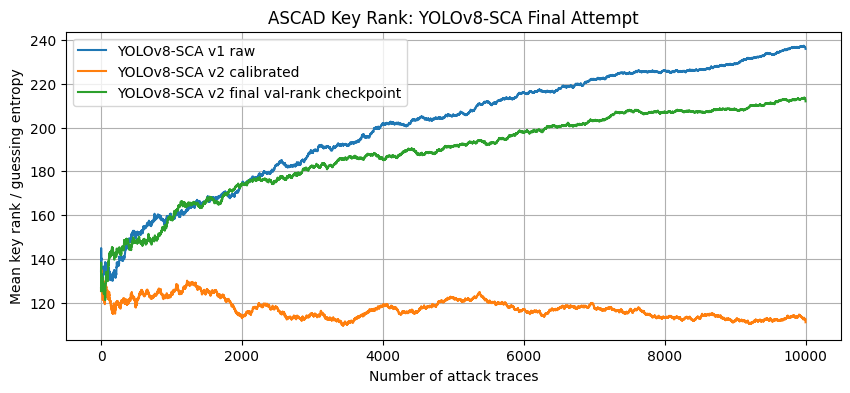

In [71]:
plt.figure(figsize=(10, 4))

try:
    plt.plot(mean_key_rank_v8, label="YOLOv8-SCA v1 raw")
except NameError:
    pass

try:
    plt.plot(mean_key_rank_v8_v2, label="YOLOv8-SCA v2 calibrated")
except NameError:
    pass

plt.plot(mean_key_rank_v8_final, label="YOLOv8-SCA v2 final val-rank checkpoint")

try:
    plt.plot(mean_key_rank_ensemble_64_96, label="Second-order MLP ensemble")
except NameError:
    pass

plt.xlabel("Number of attack traces")
plt.ylabel("Mean key rank / guessing entropy")
plt.title("ASCAD Key Rank: YOLOv8-SCA Final Attempt")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
callbacks_v8_v2 = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_yolov8_sca_v2.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

history_v8_v2 = yolov8_sca_v2.fit(
    train_ds_v2,
    validation_data=val_ds_v2,
    epochs=150,
    callbacks=callbacks_v8_v2,
    verbose=1
)

Epoch 1/150


2026-06-18 08:54:07.041337: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 08:54:07.185440: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.0033 - loss: 5.5750

2026-06-18 08:54:53.720608: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 08:54:53.861310: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 150ms/step - accuracy: 0.0038 - loss: 5.5640 - val_accuracy: 0.0028 - val_loss: 5.5528 - learning_rate: 3.0000e-04
Epoch 2/150
352/352 ━━━━━━━━━━━━━━━━━━━━ 35s 98ms/step - accuracy: 0.0051 - loss: 5.5495 - val_accuracy: 0.0048 - val_loss: 5.5534 - learning_rate: 3.0000e-04
Epoch 3/150
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 92ms/step - accuracy: 0.0056 - loss: 5.5401 - val_accuracy: 0.0044 - val_loss: 5.5600 - learning_rate: 3.0000e-04
Epoch 4/150
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.0068 - loss: 5.5258 - val_accuracy: 0.0026 - val_loss: 5.5560 - learning_rate: 3.0000e-04
Epoch 5/150
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.0090 - loss: 5.4968 - val_accuracy: 0.0020 - val_loss: 5.5643 - learning_rate: 3.0000e-04
Epoch 6/150
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.0139 - loss: 5.4348 - val_accuracy: 0.0030 - val_loss: 5.5973 - learning_rate: 3.0000e-04
Epoch 7/150
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - a

In [56]:
val_scores_v8_v2 = yolov8_sca_v2.predict(
    val_ds_v2,
    verbose=1
)

polarity_v8_v2 = choose_logit_polarity(
    val_scores_v8_v2,
    name="YOLOv8-SCA-v2"
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step

YOLOv8-SCA-v2 validation raw logits
Mean key rank after 1 trace: 125.4
Mean key rank after 10 traces: 115.4
Mean key rank after 50 traces: 104.4
Mean key rank after 100 traces: 123.9
Mean key rank after 500 traces: 137.85
Mean key rank after 1000 traces: 111.65
Mean key rank after 5000 traces: 107.0
Final mean key rank: 107.0

YOLOv8-SCA-v2 validation negative logits
Mean key rank after 1 trace: 129.6
Mean key rank after 10 traces: 139.6
Mean key rank after 50 traces: 150.6
Mean key rank after 100 traces: 131.1
Mean key rank after 500 traces: 117.15
Mean key rank after 1000 traces: 143.35
Mean key rank after 5000 traces: 148.0
Final mean key rank: 148.0
YOLOv8-SCA-v2 chosen polarity: POSITIVE


In [57]:
test_scores_v8_v2_raw = yolov8_sca_v2.predict(
    attack_ds_v2,
    verbose=1
)

test_scores_v8_v2 = polarity_v8_v2 * test_scores_v8_v2_raw

mean_key_rank_v8_v2, key_rank_runs_v8_v2 = compute_mean_key_rank(
    test_scores_v8_v2,
    plaintexts_attack,
    keys_attack,
    n_runs=100,
    name="YOLOv8-SCA-v2 calibrated"
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step

YOLOv8-SCA-v2 calibrated
Mean key rank after 1 trace: 125.3
Mean key rank after 10 traces: 134.81
Mean key rank after 50 traces: 120.53
Mean key rank after 100 traces: 123.32
Mean key rank after 500 traces: 118.77
Mean key rank after 1000 traces: 123.89
Mean key rank after 5000 traces: 122.06
Final mean key rank: 111.0


In [58]:
tf.keras.backend.clear_session()

yolo11_sca_v2 = build_yolo11_sca_v2(
    input_shape=(64, 64, 5),
    num_classes=256,
    width=1.0
)

yolo11_sca_v2.summary()

Model: "YOLO11_SCA_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 5) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │      1,440 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_silu           │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c3k2_cv1_co… │ (None, 64, 64,    │      1,024 │ stem_silu[0][0]   │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c3k2_cv1_bn  │ (None, 64, 64,    │        128 │ stage0_c3k2_cv1_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c3k2_cv1_si… │ (None, 64, 64,    │          0 │ stage0_c3k2_cv1_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c3k2_k3a_0_… │ (None, 64, 64,    │      9,216 │ stage0_c3k2_cv1_… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c3k2_k3a_0_… │ (None, 64, 64,    │        128 │ stage0_c3k2_k3a_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c3k2_k3a_0_… │ (None, 64, 64,    │          0 │ stage0_c3k2_k3a_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c3k2_k3b_0_… │ (None, 64, 64,    │      9,216 │ stage0_c3k2_k3a_… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c3k2_k3b_0_… │ (None, 64, 64,    │        128 │ stage0_c3k2_k3b_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c3k2_k3b_0_… │ (None, 64, 64,    │          0 │ stage0_c3k2_k3b_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage0_c3k2_add     │ (None, 64, 64,    │          0 │ stage0_c3k2_cv1_… │
│ (Add)               │ 32)               │            │ stage0_c3k2_k3b_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_down_conv    │ (None, 32, 32,    │     18,432 │ stage0_c3k2_add[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_down_bn      │ (None, 32, 32,    │        256 │ stage1_down_conv… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_down_silu    │ (None, 32, 32,    │          0 │ stage1_down_bn[0

 Total params: 13,677,875 (52.18 MB)

 Trainable params: 13,674,611 (52.16 MB)

 Non-trainable params: 3,264 (12.75 KB)

In [59]:
callbacks_11_v2 = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_yolo11_sca_v2.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

history_11_v2 = yolo11_sca_v2.fit(
    train_ds_v2,
    validation_data=val_ds_v2,
    epochs=150,
    callbacks=callbacks_11_v2,
    verbose=1
)

Epoch 1/150


2026-06-18 09:11:28.004823: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 09:11:28.158052: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.0033 - loss: 5.5989

2026-06-18 09:12:29.594173: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-18 09:12:29.743940: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


352/352 ━━━━━━━━━━━━━━━━━━━━ 93s 192ms/step - accuracy: 0.0035 - loss: 5.5703 - val_accuracy: 0.0038 - val_loss: 5.5517 - learning_rate: 3.0000e-04
Epoch 2/150
352/352 ━━━━━━━━━━━━━━━━━━━━ 51s 145ms/step - accuracy: 0.0046 - loss: 5.5486 - val_accuracy: 0.0046 - val_loss: 5.5493 - learning_rate: 3.0000e-04
Epoch 3/150
352/352 ━━━━━━━━━━━━━━━━━━━━ 49s 139ms/step - accuracy: 0.0063 - loss: 5.5393 - val_accuracy: 0.0046 - val_loss: 5.5515 - learning_rate: 3.0000e-04
Epoch 4/150
352/352 ━━━━━━━━━━━━━━━━━━━━ 49s 140ms/step - accuracy: 0.0063 - loss: 5.5215 - val_accuracy: 0.0030 - val_loss: 5.5535 - learning_rate: 3.0000e-04
Epoch 5/150
352/352 ━━━━━━━━━━━━━━━━━━━━ 49s 139ms/step - accuracy: 0.0092 - loss: 5.4897 - val_accuracy: 0.0040 - val_loss: 5.5608 - learning_rate: 3.0000e-04
Epoch 6/150
352/352 ━━━━━━━━━━━━━━━━━━━━ 49s 140ms/step - accuracy: 0.0147 - loss: 5.4248 - val_accuracy: 0.0034 - val_loss: 5.5938 - learning_rate: 3.0000e-04
Epoch 7/150
352/352 ━━━━━━━━━━━━━━━━━━━━ 49s 140ms/s

In [60]:
val_scores_11_v2 = yolo11_sca_v2.predict(
    val_ds_v2,
    verbose=1
)

polarity_11_v2 = choose_logit_polarity(
    val_scores_11_v2,
    name="YOLO11-SCA-v2"
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step

YOLO11-SCA-v2 validation raw logits
Mean key rank after 1 trace: 120.95
Mean key rank after 10 traces: 131.35
Mean key rank after 50 traces: 122.35
Mean key rank after 100 traces: 120.55
Mean key rank after 500 traces: 98.9
Mean key rank after 1000 traces: 70.55
Mean key rank after 5000 traces: 1.0
Final mean key rank: 1.0

YOLO11-SCA-v2 validation negative logits
Mean key rank after 1 trace: 134.05
Mean key rank after 10 traces: 123.65
Mean key rank after 50 traces: 132.65
Mean key rank after 100 traces: 134.45
Mean key rank after 500 traces: 156.1
Mean key rank after 1000 traces: 184.45
Mean key rank after 5000 traces: 254.0
Final mean key rank: 254.0
YOLO11-SCA-v2 chosen polarity: POSITIVE


In [61]:
test_scores_11_v2_raw = yolo11_sca_v2.predict(
    attack_ds_v2,
    verbose=1
)

test_scores_11_v2 = polarity_11_v2 * test_scores_11_v2_raw

mean_key_rank_11_v2, key_rank_runs_11_v2 = compute_mean_key_rank(
    test_scores_11_v2,
    plaintexts_attack,
    keys_attack,
    n_runs=100,
    name="YOLO11-SCA-v2 calibrated"
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step

YOLO11-SCA-v2 calibrated
Mean key rank after 1 trace: 132.89
Mean key rank after 10 traces: 129.07
Mean key rank after 50 traces: 129.79
Mean key rank after 100 traces: 126.79
Mean key rank after 500 traces: 130.9
Mean key rank after 1000 traces: 129.96
Mean key rank after 5000 traces: 123.97
Final mean key rank: 115.0


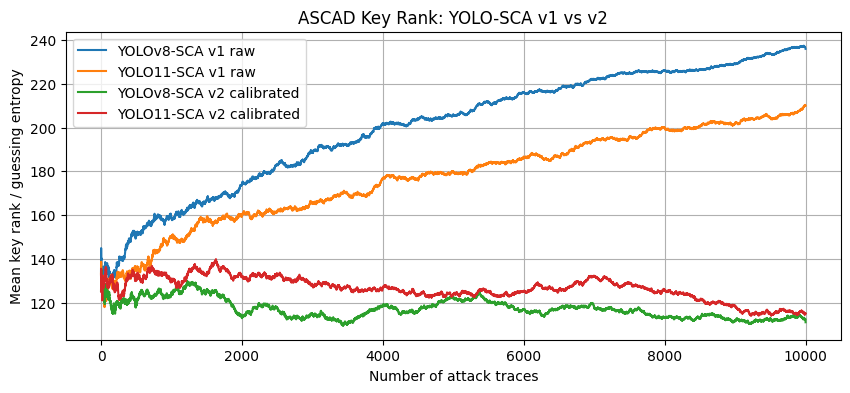

In [62]:
plt.figure(figsize=(10, 4))

try:
    plt.plot(mean_key_rank_v8, label="YOLOv8-SCA v1 raw")
except NameError:
    pass

try:
    plt.plot(mean_key_rank_11, label="YOLO11-SCA v1 raw")
except NameError:
    pass

plt.plot(mean_key_rank_v8_v2, label="YOLOv8-SCA v2 calibrated")
plt.plot(mean_key_rank_11_v2, label="YOLO11-SCA v2 calibrated")

try:
    plt.plot(mean_key_rank_ensemble_64_96, label="Second-order MLP ensemble")
except NameError:
    pass

plt.xlabel("Number of attack traces")
plt.ylabel("Mean key rank / guessing entropy")
plt.title("ASCAD Key Rank: YOLO-SCA v1 vs v2")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
np.savetxt(
    "/kaggle/working/yolov8_sca_v2_mean_key_rank.txt",
    mean_key_rank_v8_v2
)

np.savetxt(
    "/kaggle/working/yolo11_sca_v2_mean_key_rank.txt",
    mean_key_rank_11_v2
)

np.savez(
    "/kaggle/working/yolo_sca_v2_results.npz",
    mean_key_rank_v8_v2=mean_key_rank_v8_v2,
    mean_key_rank_11_v2=mean_key_rank_11_v2,
    key_rank_runs_v8_v2=key_rank_runs_v8_v2,
    key_rank_runs_11_v2=key_rank_runs_11_v2,
    polarity_v8_v2=polarity_v8_v2,
    polarity_11_v2=polarity_11_v2,
    poi_mask=poi_mask,
    poi_masked_value=poi_masked_value,
    A_mean=A_mean,
    A_std=A_std,
    B_mean=B_mean,
    B_std=B_std,
    P_mean=P_mean,
    P_std=P_std,
    trace_mean=trace_mean
)

yolov8_sca_v2.save("/kaggle/working/final_yolov8_sca_v2.keras")
yolo11_sca_v2.save("/kaggle/working/final_yolo11_sca_v2.keras")

print("Saved YOLO-SCA-v2 results.")

Saved YOLO-SCA-v2 results.


In [72]:
import os
import shutil
import numpy as np

YOLO_SAVE_DIR = "/kaggle/working/yolo_saved_results"
os.makedirs(YOLO_SAVE_DIR, exist_ok=True)

print("Saving to:", YOLO_SAVE_DIR)

Saving to: /kaggle/working/yolo_saved_results


In [73]:
def save_if_exists(var_name, filename):
    if var_name in globals():
        np.save(
            os.path.join(YOLO_SAVE_DIR, filename),
            globals()[var_name]
        )
        print("Saved:", filename)
    else:
        print("Missing:", var_name)

save_if_exists("mean_key_rank_v8", "mean_key_rank_v8.npy")
save_if_exists("mean_key_rank_11", "mean_key_rank_11.npy")
save_if_exists("mean_key_rank_v8_v2", "mean_key_rank_v8_v2.npy")
save_if_exists("mean_key_rank_11_v2", "mean_key_rank_11_v2.npy")
save_if_exists("mean_key_rank_v8_final", "mean_key_rank_v8_final.npy")

Saved: mean_key_rank_v8.npy
Saved: mean_key_rank_11.npy
Saved: mean_key_rank_v8_v2.npy
Saved: mean_key_rank_11_v2.npy
Saved: mean_key_rank_v8_final.npy


In [74]:
if "yolov8_sca" in globals():
    yolov8_sca.save(
        os.path.join(YOLO_SAVE_DIR, "yolov8_sca_v1.keras")
    )

if "yolo11_sca" in globals():
    yolo11_sca.save(
        os.path.join(YOLO_SAVE_DIR, "yolo11_sca_v1.keras")
    )

if "yolov8_sca_v2" in globals():
    yolov8_sca_v2.save(
        os.path.join(YOLO_SAVE_DIR, "yolov8_sca_v2.keras")
    )

if "yolo11_sca_v2" in globals():
    yolo11_sca_v2.save(
        os.path.join(YOLO_SAVE_DIR, "yolo11_sca_v2.keras")
    )

if "yolov8_sca_v2_final" in globals():
    yolov8_sca_v2_final.save(
        os.path.join(YOLO_SAVE_DIR, "yolov8_sca_v2_final.keras")
    )

print("Models saved")

Models saved


Saved: /kaggle/working/yolo_saved_results/yolo_key_rank_comparison.png


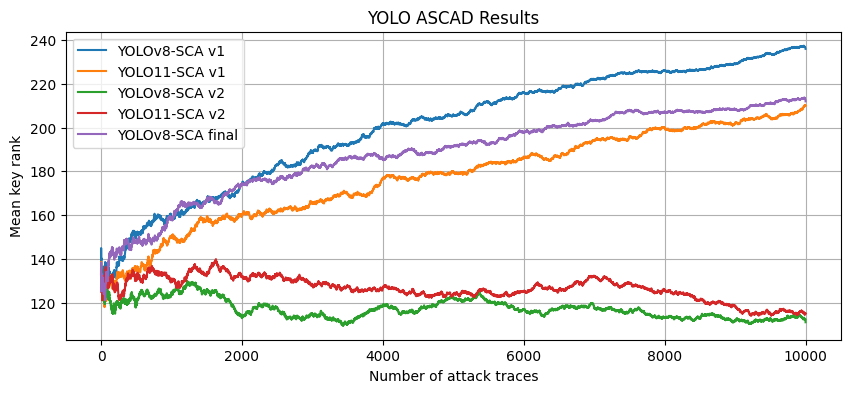

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

if "mean_key_rank_v8" in globals():
    plt.plot(mean_key_rank_v8, label="YOLOv8-SCA v1")

if "mean_key_rank_11" in globals():
    plt.plot(mean_key_rank_11, label="YOLO11-SCA v1")

if "mean_key_rank_v8_v2" in globals():
    plt.plot(mean_key_rank_v8_v2, label="YOLOv8-SCA v2")

if "mean_key_rank_11_v2" in globals():
    plt.plot(mean_key_rank_11_v2, label="YOLO11-SCA v2")

if "mean_key_rank_v8_final" in globals():
    plt.plot(mean_key_rank_v8_final, label="YOLOv8-SCA final")

plt.xlabel("Number of attack traces")
plt.ylabel("Mean key rank")
plt.title("YOLO ASCAD Results")
plt.legend()
plt.grid(True)

plot_path = os.path.join(YOLO_SAVE_DIR, "yolo_key_rank_comparison.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

print("Saved:", plot_path)

In [76]:
summary = """
YOLO ASCAD RESULTS

YOLOv8-SCA v1:
Final mean key rank: 236

YOLO11-SCA v1:
Final mean key rank: 210

YOLOv8-SCA v2:
Final mean key rank: ~111

YOLO11-SCA v2:
Final mean key rank: ~115

YOLOv8-SCA final validation-rank checkpoint:
Final mean key rank: 212

Conclusion:
YOLO-style spatial modeling did not successfully recover the key.
Second-order MLP ensemble remains strongest model.
"""

with open(
    os.path.join(YOLO_SAVE_DIR, "yolo_summary.txt"),
    "w"
) as f:
    f.write(summary)

print("Summary saved")

Summary saved


In [77]:
zip_path = shutil.make_archive(
    "/kaggle/working/yolo_saved_results",
    "zip",
    YOLO_SAVE_DIR
)

print("Created:", zip_path)

Created: /kaggle/working/yolo_saved_results.zip


In [78]:
!ls -lh /kaggle/working/yolo_saved_results.zip

-rw-r--r-- 1 root root 472M Jun 18 11:18 /kaggle/working/yolo_saved_results.zip
